<a href="https://colab.research.google.com/github/sophieangulo/NNs-for-tampa-restaurant-cleanliness/blob/main/Tampa_Hygiene_Baselines_FusionNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Restaurant Cleanliness Detection in Tampa Bay

**BA 510 Final Project**  by Aryan Karki & Sophie Angulo

Our project notebook trains a three-modality nn that predicts whether a Tampa-area restaurant is likely to have a hygiene concern, defined as one or more high-priority violations on its most recent Florida DBPR inspection.

The three inputs are:

1. **Review text** — up to 20 most-recent Yelp reviews per restaurant, encoded with a frozen **RoBERTa** backbone via `keras_hub` (the exact pattern from Week 10 lecture 10.2).
2. **Structured Yelp features** — stars, review count, cuisine multi-hot, geography, community votes, plus lightweight photo-derived statistics (brightness / contrast / label mix / photo count).
3. **Restaurant images** — up to 10 Yelp reviewer photos per restaurant, encoded with a frozen **VGG16** backbone via `keras.applications` (the pattern from Week 5 lecture 5.4), then mean-pooled to a single per-restaurant vector.


The model is a **FusionNet** merged with `layers.Concatenate()` in the keras functional API.

**The Tampa dataset** contains 2,653 restaurants × 334,342 review texts × 11,877 reviewer photos across 1,771 restaurants (median 4 photos/restaurant), joined to the FL DBPR FY 2024-25 inspection records via fuzzy name + ZIP matching.


## Installation and Setup

In [ ]:
# installing keras_hub
try:
    import keras_hub
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "keras_hub"], check=True)
    import keras_hub

# taking care of lightweight PIL-based photo features
try:
    from PIL import Image
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "Pillow"], check=True)

# re-running the fuzzy-match
try:
    from thefuzz import process as _fz
except ImportError:
    pass


In [ ]:
# regular schmegular imports
import os, re, json, random, gzip, warnings, math, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow", tf.__version__, "·", "Keras", keras.__version__, "·", "keras_hub", keras_hub.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow 2.20.0 · Keras 3.13.2 · keras_hub 0.26.0
GPU available: True


In [ ]:
# mounting drive
from google.colab import drive
drive.mount('/content/gdrive')

import os, glob, zipfile

ZIP_CANDIDATES = sorted(glob.glob('/content/gdrive/MyDrive/Yelp*BA510*.zip')) \
              + sorted(glob.glob('/content/gdrive/MyDrive/Yelp*Hygiene*.zip'))
ZIP = next((p for p in ZIP_CANDIDATES if os.path.exists(p)), None)
assert ZIP, f'zip not found in MyDrive. Searched: {ZIP_CANDIDATES}'
print('found zip:', ZIP, '·', round(os.path.getsize(ZIP) / 2**20, 1), 'MB')

# unzipping yelp data folder
EXTRACT_TO = '/content/yelp_data'
os.makedirs(EXTRACT_TO, exist_ok=True)
print('unzipping …')
with zipfile.ZipFile(ZIP) as z:
    z.extractall(EXTRACT_TO)
print('done — top-level entries:', sorted(os.listdir(EXTRACT_TO))[:8])

def _find_data_dir(root):
    for cand in [root] + [os.path.join(root, d) for d in os.listdir(root)
                          if os.path.isdir(os.path.join(root, d))]:
        if 'tampa_business_inspections.csv' in os.listdir(cand):
            return cand
    raise FileNotFoundError(f'could not find tampa_business_inspections.csv under {root}')

DRIVE_DATA_DIR = _find_data_dir(EXTRACT_TO)
print('DRIVE_DATA_DIR:', DRIVE_DATA_DIR)

# path variables
BIZ_CSV     = os.path.join(DRIVE_DATA_DIR, 'tampa_business_inspections.csv')
REVIEWS_CSV = os.path.join(DRIVE_DATA_DIR, 'tampa_reviews_inspections.csv')
PHOTOS_JSON = os.path.join(DRIVE_DATA_DIR, 'tampa_photos.json')
PHOTOS_DIR  = os.path.join(DRIVE_DATA_DIR, 'photos')

# cache embeddings
CACHE_DIR = '/content/gdrive/MyDrive/yelp_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

print('biz CSV     :', os.path.exists(BIZ_CSV))
print('reviews CSV :', os.path.exists(REVIEWS_CSV))
print('photos JSON :', os.path.exists(PHOTOS_JSON))
print('photos dir  :', os.path.exists(PHOTOS_DIR),
      '·', len(os.listdir(PHOTOS_DIR)) if os.path.isdir(PHOTOS_DIR) else 0, 'files')
print('CACHE_DIR   :', CACHE_DIR)



Mounted at /content/gdrive
found zip: /content/gdrive/MyDrive/Yelp Hygiene Ratings BA510.zip · 538.0 MB
unzipping …
done — top-level entries: ['Yelp Hygiene Ratings']
DRIVE_DATA_DIR: /content/yelp_data/Yelp Hygiene Ratings
biz CSV     : True
reviews CSV : True
photos JSON : True
photos dir  : True · 11877 files
CACHE_DIR   : /content/gdrive/MyDrive/yelp_cache


## Data Import

Three files being loaded below:

1. `tampa_business_inspections.csv`: one row per restaurant (2,653 × 95), with Yelp metadata + the most-recent FL DBPR inspection record + DBPR violation flags.
2. `tampa_reviews_inspections.csv`: one row per review (~334,000 × 35), with full review text and per-review metadata.
3. `tampa_photos.json`: photo metadata array where each entry maps `photo_id` with `business_id` + `label` + `caption`.

In [ ]:
# per restaurant table
biz = pd.read_csv(BIZ_CSV, low_memory=False)
print('business table     :', biz.shape)

# per review table
# this file is large (334k rows) so we only used a handful of columns per review,
# to keep memory down.
REVIEW_COLS = ['business_id', 'review_text', 'review_stars', 'review_date',
               'review_useful', 'review_funny', 'review_cool']
reviews = pd.read_csv(REVIEWS_CSV, usecols=REVIEW_COLS, low_memory=False)
print('reviews table      :', reviews.shape)

# photo metadata
with open(PHOTOS_JSON) as f:
    photos_meta = pd.DataFrame(json.load(f))
print('photo metadata     :', photos_meta.shape)
print('  unique businesses w/ photos:', photos_meta['business_id'].nunique())


business table     : (2653, 95)
reviews table      : (334342, 7)
photo metadata     : (11877, 4)
  unique businesses w/ photos: 1771


### Build the per-restaurant table

1. **Review aggregates**: per `business_id`, sort reviews by date, take the most-recent **20** reviews and concatenate their text into `reviews_concat`. Also compute `mean_review_stars`, `std_review_stars`, `n_reviews_all`, `total_useful`, `total_funny`, `total_cool`.
2. **Photo aggregates**: per `business_id` from `tampa_photos.json`, count photos and label-share for the five Yelp categories (food / inside / outside / drink / menu).
3. **PIL stats per restaurant**: open each JPEG and average per restaurant: brightness, contrast, saturation, warmth, low-light-rate, high-light-rate.
4. **Merge** on business_id

In [ ]:
# review aggregates
reviews['review_date'] = pd.to_datetime(reviews['review_date'], errors='coerce')

def _top20_concat(group, k=20):
    g = group.sort_values('review_date', ascending=False).head(k)
    return ' \n'.join(g['review_text'].fillna('').astype(str).tolist())

print('aggregating', len(reviews), 'reviews → per-business …')
review_agg = (reviews.groupby('business_id')
                     .agg(mean_review_stars=('review_stars', 'mean'),
                          std_review_stars =('review_stars', 'std'),
                          n_reviews_all    =('review_stars', 'size'),
                          total_useful     =('review_useful', 'sum'),
                          total_funny      =('review_funny',  'sum'),
                          total_cool       =('review_cool',   'sum'))
                     .reset_index())
review_text = (reviews.groupby('business_id', sort=False)
                      .apply(_top20_concat).rename('reviews_concat').reset_index())
review_agg  = review_agg.merge(review_text, on='business_id', how='left')
print('review_agg shape  :', review_agg.shape)


aggregating 334342 reviews → per-business …
review_agg shape  : (2653, 8)


In [ ]:
# photo aggregates from tampa_photos.json
PHOTO_LABELS = ['food', 'inside', 'outside', 'drink', 'menu']

photos_meta = photos_meta[photos_meta['business_id'].isin(biz['business_id'])].copy()
photos_meta['label'] = photos_meta['label'].fillna('').astype(str)

counts = photos_meta.groupby('business_id').size().rename('n_photos').reset_index()
label_share = (
    photos_meta.assign(_one=1)
               .pivot_table(index='business_id', columns='label',
                            values='_one', aggfunc='sum', fill_value=0)
               .reindex(columns=PHOTO_LABELS, fill_value=0)
)
label_share = label_share.div(label_share.sum(axis=1).replace(0, 1), axis=0)
label_share.columns = [f'pct_{c}' for c in label_share.columns]
label_share = label_share.reset_index()
photo_agg = counts.merge(label_share, on='business_id', how='left')
photo_agg['has_photos'] = 1
print('photo_agg shape   :', photo_agg.shape)
photo_agg.head(3)


photo_agg shape   : (1771, 8)


,business_id,n_photos,pct_food,pct_inside,pct_outside,pct_drink,pct_menu,has_photos
0,-1oygVebK81K8JEPI6H6Lw,7,0.857143,0.142857,0.0,0.000000,0.0,1
1,-2BDt9OdGiBONysWCdKgNg,6,0.833333,0.000000,0.0,0.166667,0.0,1
2,-2YZIUArmrIMVVBi8CT47w,1,1.000000,0.000000,0.0,0.000000,0.0,1


In [ ]:
# PIL-based per-photo stats (cached)
# opening each JPEG once at thumbnail size, compute brightness / contrast /
# saturation / warmth / low-light-rate / high-light-rate, then average per
# restaurant
from PIL import Image as PILImage

PIL_CACHE = os.path.join(CACHE_DIR, 'photo_pil_features.csv.gz')

def _pil_feats(path, side=64):
    try:
        img = PILImage.open(path).convert('RGB').resize((side, side))
    except Exception:
        return None
    arr = np.asarray(img, dtype='float32') / 255.0
    r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]
    brightness = arr.mean()
    contrast   = arr.std()
    mx, mn = arr.max(axis=-1), arr.min(axis=-1)
    saturation = (mx - mn).mean()
    warmth     = (r.mean() - b.mean())
    luma = 0.299 * r + 0.587 * g + 0.114 * b
    low_light  = (luma < 0.20).mean()
    high_light = (luma > 0.85).mean()
    return [brightness, contrast, saturation, warmth, low_light, high_light]

if os.path.exists(PIL_CACHE):
    photo_pil = pd.read_csv(PIL_CACHE)
    print('loaded PIL features from cache', photo_pil.shape)
else:
    rows = []
    for i, (pid, biz_id) in enumerate(zip(photos_meta['photo_id'], photos_meta['business_id'])):
        path = os.path.join(PHOTOS_DIR, f'{pid}.jpg')
        if not os.path.exists(path):
            continue
        feats = _pil_feats(path)
        if feats is None:
            continue
        rows.append([pid, biz_id] + feats)
        if (i+1) % 2000 == 0:
            print(f'  {i+1:,} / {len(photos_meta):,} photos processed …')
    photo_pil = pd.DataFrame(rows, columns=['photo_id', 'business_id',
                                            'brightness', 'contrast', 'saturation',
                                            'warmth', 'low_light', 'high_light'])
    photo_pil.to_csv(PIL_CACHE, index=False, compression='gzip')
    print('cached PIL features', photo_pil.shape)

pil_agg = (photo_pil.groupby('business_id')
                    .agg(mean_brightness =('brightness',  'mean'),
                         mean_contrast   =('contrast',    'mean'),
                         mean_saturation =('saturation',  'mean'),
                         mean_warmth     =('warmth',      'mean'),
                         low_light_rate  =('low_light',   'mean'),
                         high_light_rate =('high_light',  'mean'))
                    .reset_index())
photo_agg = photo_agg.merge(pil_agg, on='business_id', how='left')
print('photo_agg shape   :', photo_agg.shape)


loaded PIL features from cache (11877, 8)
photo_agg shape   : (1771, 14)


In [ ]:
# merge into the final per-restaurant df
df = (biz.merge(review_agg, on='business_id', how='left')
         .merge(photo_agg,  on='business_id', how='left'))

# professor if you see this: i mentioned in class that we dropped restaurants
# with no photos; i thought about that and realized that was dumb so i found this
# 'zero fillling' photo aggregate option and flag_photos = 0 by prompting claude
# and i believe this was a much better option; we lost 1/3 of our dataset by
# dropping retaurants with no photos and it significantly affected accuracy.
PHOTO_COLS_NUM = ['n_photos', 'pct_food', 'pct_inside', 'pct_outside', 'pct_drink', 'pct_menu',
                  'mean_brightness', 'mean_contrast', 'mean_saturation', 'mean_warmth',
                  'low_light_rate', 'high_light_rate']
df[PHOTO_COLS_NUM] = df[PHOTO_COLS_NUM].fillna(0)
df['has_photos']   = df['has_photos'].fillna(0).astype(int)

print('final per-restaurant df:', df.shape)
df.head(3)


final per-restaurant df: (2653, 115)


,business_id,yelp_name,yelp_address,yelp_city,yelp_postal_code,yelp_latitude,yelp_longitude,yelp_stars,yelp_review_count,yelp_categories,...,pct_outside,pct_drink,pct_menu,has_photos,mean_brightness,mean_contrast,mean_saturation,mean_warmth,low_light_rate,high_light_rate
0,Ucl9Vo5lwrUmYbV8Dv8X5g,O'Briens Irish Pub,15435 N Dale Mabry Hwy,Tampa,33618,28.092360,-82.500588,4.0,108,"Bars, Pubs, Nightlife, Arts & Entertainment, I...",...,0.0,0.0,0.0,1,0.275330,0.201104,0.103463,0.092487,0.421021,0.014648
1,VVvUBlc_WIEb8obKGq39dA,Four Green Fields,"4100 George J Bean Pkwy, Airside E, Tampa Inte...",Tampa,33607,27.980399,-82.537787,4.5,39,"Irish Pub, Bars, Restaurants, Irish, Nightlife",...,0.0,1.0,0.0,1,0.350854,0.226486,0.136395,0.097713,0.298584,0.000732
2,XwoXi0M66RU6Gouq-DSDHw,G Peppers Grill & Tavern,8745 Gunn Hwy,Odessa,33556,28.092136,-82.578574,4.0,82,"Restaurants, Mexican, American (Traditional)",...,0.0,0.0,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Descriptive Statistics

We define the **target** as a high-priority violation indicator:

> `label = 1` iff the restaurant had ≥ 1 high-priority violation on its most recent FL DBPR inspection, else 0.

In [ ]:
# define binary label
df['label'] = (df['HIGH_VIOL'].fillna(0) >= 1).astype(int)
print('class balance (label rate):', round(df['label'].mean(), 3))
print('n restaurants:', len(df))
print('photo coverage:', round(df['has_photos'].mean(), 3))


class balance (label rate): 0.47
n restaurants: 2653
photo coverage: 0.668


In [ ]:
# missingness snapshot for the most informative columns
cols = ['yelp_stars','yelp_review_count','mean_review_stars','n_reviews_all',
        'n_photos','mean_brightness','CNTY_DESC','INSPTYPE','HIGH_VIOL']
miss = df[cols].isna().mean().sort_values(ascending=False).round(3)
print(miss)


yelp_stars           0.0
yelp_review_count    0.0
mean_review_stars    0.0
n_reviews_all        0.0
n_photos             0.0
mean_brightness      0.0
CNTY_DESC            0.0
INSPTYPE             0.0
HIGH_VIOL            0.0
dtype: float64


In [ ]:
# violation col numerical summary
df[['HIGH_VIOL', 'label']].describe().round(3)

,HIGH_VIOL,label
count,2653.000,2653.000
mean,0.811,0.470
std,1.135,0.499
min,0.000,0.000
25%,0.000,0.000
50%,0.000,0.000
75%,1.000,1.000
max,8.000,1.000


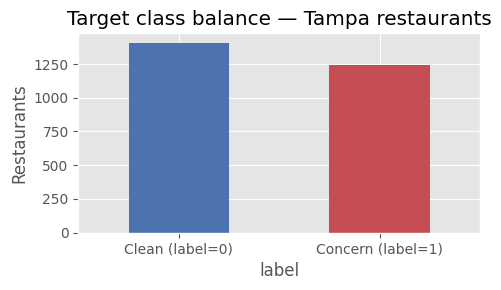

In [ ]:
# target class balance plot
plt.figure(figsize=(5,3))
df['label'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0','#C44E52'])
plt.xticks([0,1], ['Clean (label=0)', 'Concern (label=1)'], rotation=0)
plt.ylabel('Restaurants'); plt.title('Target class balance — Tampa restaurants')
plt.tight_layout(); plt.show()


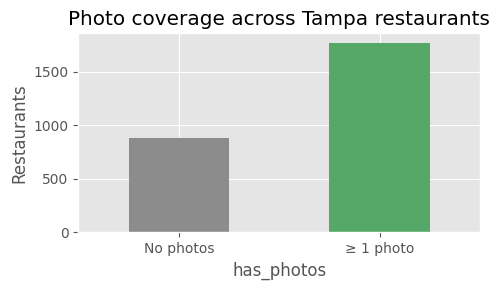

restaurants with photos: 1771 / 2653


In [ ]:
# photo coverage bar graph
cov = df['has_photos'].value_counts().sort_index()
plt.figure(figsize=(5,3))
cov.plot(kind='bar', color=['#8C8C8C','#55A868'])
plt.xticks([0,1], ['No photos','≥ 1 photo'], rotation=0)
plt.ylabel('Restaurants'); plt.title('Photo coverage across Tampa restaurants')
plt.tight_layout(); plt.show()
print('restaurants with photos:', int(cov.get(1,0)), '/', len(df))


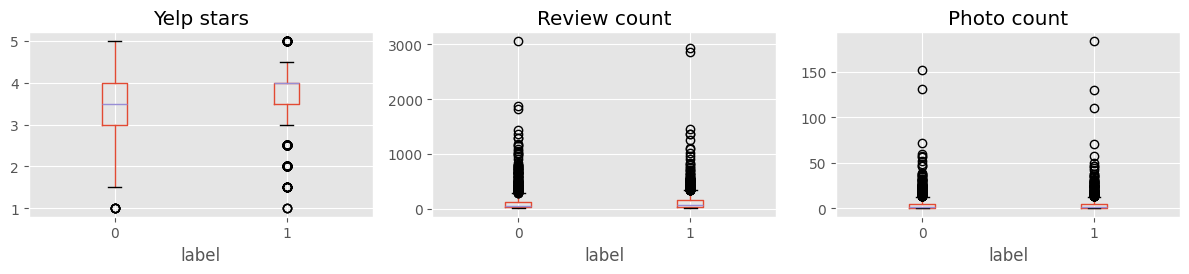

In [ ]:
# univariate boxplots - do stars / review volume / photo count separate the classes?
fig, axes = plt.subplots(1, 3, figsize=(12,3))
for ax, col, ttl in zip(axes,
                        ['yelp_stars', 'yelp_review_count', 'n_photos'],
                        ['Yelp stars', 'Review count', 'Photo count']):
    df.boxplot(column=col, by='label', ax=ax)
    ax.set_title(ttl); ax.set_xlabel('label')
plt.suptitle(''); plt.tight_layout(); plt.show()


## Preprocessing

Three preprocessing tracks, one per modality:

- **Text**: strip URLs, collapse whitespace, cap at 4,000 chars.
- **Structured**: median-impute numerics, multi-hot top-15 cuisine tags, one-hot `CNTY_DESC` + `INSPTYPE`. Photo-aggregate features (brightness / contrast / label mix) are included as ordinary numerics with a `has_photos` flag so the model can learn a "ignore image stats if none" routing.
- **Image**: per-restaurant list of ≤ 10 JPEGs, resized to 224 × 224 at load time in §10. For restaurants with no photos we pass a zero tensor and rely on the `has_photos` structured flag.


In [ ]:
# text cleaning
URL_RE = re.compile(r'https?://\S+|www\.\S+')
WS_RE  = re.compile(r'\s+')
def clean_text(s, cap=4000):
    s = URL_RE.sub(' ', str(s))
    s = WS_RE.sub(' ', s).strip()
    return s[:cap]

df['text'] = df['reviews_concat'].fillna('').map(clean_text)
df['text'].str.len().describe().round(0)


,text
count,2653.0
mean,3922.0
std,357.0
min,918.0
25%,4000.0
50%,4000.0
75%,4000.0
max,4000.0


In [ ]:
# structured columns
STRUCT_NUMERIC = [
    'yelp_stars', 'yelp_review_count', 'yelp_latitude', 'yelp_longitude',
    'mean_review_stars', 'std_review_stars', 'n_reviews_all',
    'total_useful', 'total_funny', 'total_cool', 'is_open',
    # lightweight photo-derived features
    'n_photos', 'mean_brightness', 'mean_contrast', 'mean_saturation',
    'mean_warmth', 'low_light_rate', 'high_light_rate',
    'pct_food', 'pct_inside', 'pct_outside', 'pct_drink', 'pct_menu', 'has_photos',
]
STRUCT_CAT = ['CNTY_DESC', 'INSPTYPE']

for c in STRUCT_NUMERIC:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df[STRUCT_NUMERIC] = df[STRUCT_NUMERIC].fillna(df[STRUCT_NUMERIC].median())
df[STRUCT_CAT]     = df[STRUCT_CAT].fillna('Unknown').astype(str)

# top-15 cuisine tags as multi-hot
top_cats = (df['yelp_categories'].fillna('').str.split(r',\s*').explode()
              .value_counts().head(15).index.tolist())
for c in top_cats:
    df[f'cat_{c.replace(" ", "_")}'] = (
        df['yelp_categories'].fillna('').str.contains(re.escape(c)).astype(int)
    )
CAT_MH = [f'cat_{c.replace(" ", "_")}' for c in top_cats]
STRUCT_ALL = STRUCT_NUMERIC + CAT_MH

print('numeric structured cols:', len(STRUCT_NUMERIC))
print('category one-hot cols  :', STRUCT_CAT)
print('cuisine multi-hots     :', len(CAT_MH))


numeric structured cols: 24
category one-hot cols  : ['CNTY_DESC', 'INSPTYPE']
cuisine multi-hots     : 15


## Train / Validation / Test Split

Stratified **70 / 15 / 15** at the restaurant level. We mentioned an 80/10/10 in the presentation for our spacy model, but our other baselines follow a 70/15/15 split.


In [ ]:
tr_full, te_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=SEED)
tr_df, va_df   = train_test_split(tr_full, test_size=0.1765, stratify=tr_full['label'], random_state=SEED)
# 0.1765 × 0.85 = 0.15 of the original, so final split is around 70/15/15.
print('sizes (tr / va / te):', len(tr_df), len(va_df), len(te_df))
print('label rates          :', [round(x['label'].mean(),3) for x in (tr_df, va_df, te_df)])


sizes (tr / va / te): 1856 399 398
label rates          : [np.float64(0.47), np.float64(0.469), np.float64(0.47)]


##  Shared Evaluation Helper

Every model below is a binary classifier, so we share one `evaluate()` helper that returns the full forecasting-practice panel: accuracy, precision, recall, F1, ROC-AUC, PR-AUC, plus confusion matrix + curves. Loss during training is `binary_crossentropy`.


In [ ]:
def evaluate(y_true, y_prob, name, show_plots=False):
    y_pred = (y_prob >= 0.5).astype(int)
    out = {
        'model': name,
        'accuracy' : round(accuracy_score(y_true, y_pred), 3),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'recall'   : round(recall_score(y_true, y_pred), 3),
        'f1'       : round(f1_score(y_true, y_pred), 3),
        'roc_auc'  : round(roc_auc_score(y_true, y_prob), 3),
        'pr_auc'   : round(average_precision_score(y_true, y_prob), 3),
    }
    if show_plots:
        fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[0].plot(fpr, tpr, lw=2); axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
        axes[0].set_title(f'ROC · AUC={out["roc_auc"]:.3f}')
        axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
        pr, rc, _ = precision_recall_curve(y_true, y_prob)
        axes[1].plot(rc, pr, lw=2); axes[1].set_title(f'PR · AUC={out["pr_auc"]:.3f}')
        axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
        ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                               display_labels=['Clean', 'Concern']).plot(ax=axes[2], colorbar=False)
        axes[2].set_title('Confusion @ 0.5')
        plt.suptitle(name); plt.tight_layout(); plt.show()
    return out

results = []


## Baseline #1: Logistic Regression on Structured Features


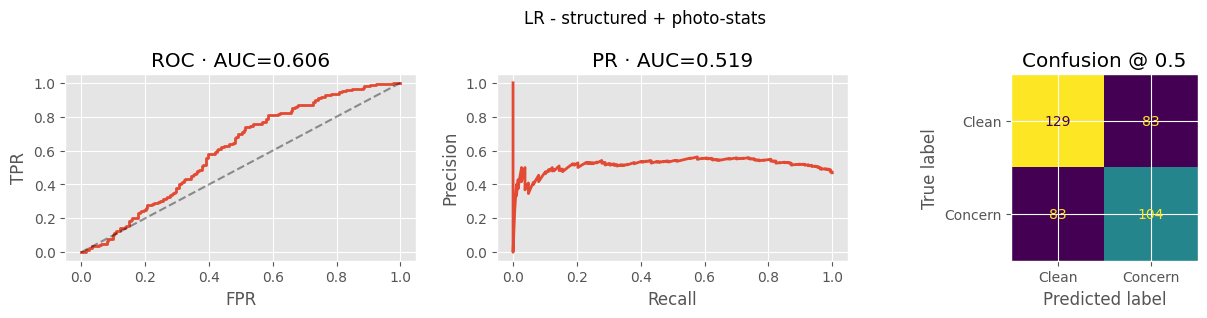

{'model': 'LR - structured + photo-stats',
 'accuracy': 0.584,
 'precision': 0.556,
 'recall': 0.556,
 'f1': 0.556,
 'roc_auc': np.float64(0.606),
 'pr_auc': np.float64(0.519)}

In [ ]:
pre = ColumnTransformer([
    ('num', StandardScaler(), STRUCT_ALL),
    ('cat', OneHotEncoder(handle_unknown='ignore'), STRUCT_CAT),
])

lr_s = Pipeline([('pre', pre),
                 ('clf', LogisticRegression(max_iter=2000, C=1.0))]).fit(tr_df, tr_df['label'])

va_prob_lr_s = lr_s.predict_proba(va_df)[:, 1]
r = evaluate(va_df['label'], va_prob_lr_s, 'LR - structured + photo-stats', show_plots=True)
results.append(r); r


## Baseline #2: Logistic Regression on TF-IDF Review Text

In [ ]:
tfidf = TfidfVectorizer(max_features=30000, min_df=3, ngram_range=(1,2),
                        sublinear_tf=True, strip_accents='unicode')
Xtr_t = tfidf.fit_transform(tr_df['text'])
Xva_t = tfidf.transform(va_df['text'])
Xte_t = tfidf.transform(te_df['text'])
print('tfidf shape (train):', Xtr_t.shape)


tfidf shape (train): (1856, 30000)


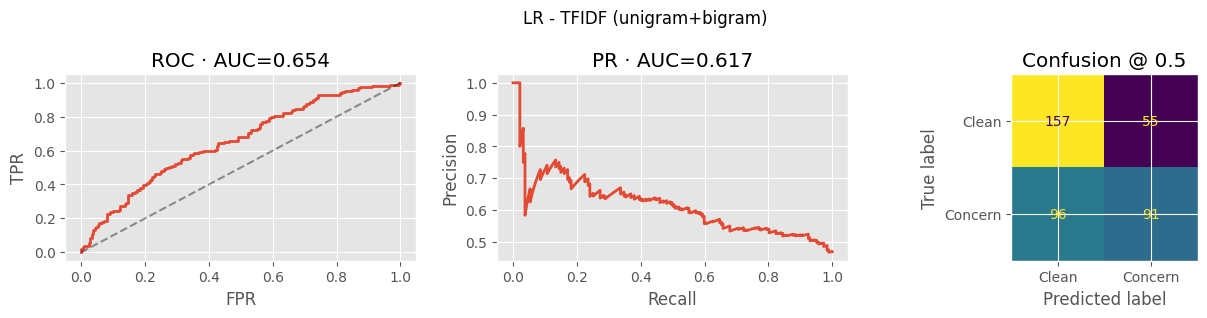

{'model': 'LR - TFIDF (unigram+bigram)',
 'accuracy': 0.622,
 'precision': 0.623,
 'recall': 0.487,
 'f1': 0.547,
 'roc_auc': np.float64(0.654),
 'pr_auc': np.float64(0.617)}

In [ ]:
lr_t = LogisticRegression(max_iter=2000, C=1.0, solver='liblinear').fit(Xtr_t, tr_df['label'])
va_prob_lr_t = lr_t.predict_proba(Xva_t)[:, 1]
r = evaluate(va_df['label'], va_prob_lr_t, 'LR - TFIDF (unigram+bigram)', show_plots=True)
results.append(r); r


## Baseline #3: Small Keras MLP on Structured Features

In [ ]:
# fit the preprocessor once; reuse the dense numeric matrix throughout.
pre_fit = pre.fit(tr_df)
Xtr_s = pre_fit.transform(tr_df)
Xva_s = pre_fit.transform(va_df)
Xte_s = pre_fit.transform(te_df)
# to_array because our fusion layers want dense
Xtr_s = np.asarray(Xtr_s.todense() if hasattr(Xtr_s,'todense') else Xtr_s).astype('float32')
Xva_s = np.asarray(Xva_s.todense() if hasattr(Xva_s,'todense') else Xva_s).astype('float32')
Xte_s = np.asarray(Xte_s.todense() if hasattr(Xte_s,'todense') else Xte_s).astype('float32')
print('structured matrix shape:', Xtr_s.shape)


structured matrix shape: (1856, 48)


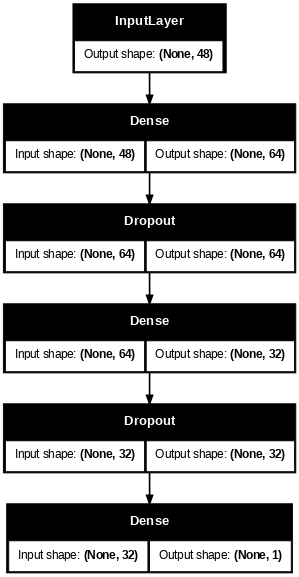

In [ ]:
# small dense NN on structured features (Functional API)
struct_in = layers.Input(shape=(Xtr_s.shape[1],), name='structured')
h = layers.Dense(64, activation='relu')(struct_in)
h = layers.Dropout(0.3)(h)
h = layers.Dense(32, activation='relu')(h)
h = layers.Dropout(0.3)(h)
out = layers.Dense(1, activation='sigmoid', name='label')(h)
mlp_struct = keras.Model(struct_in, out, name='mlp_struct')
mlp_struct.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
keras.utils.plot_model(mlp_struct, show_shapes=True, dpi=60)


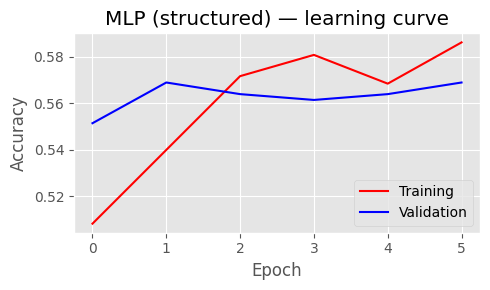

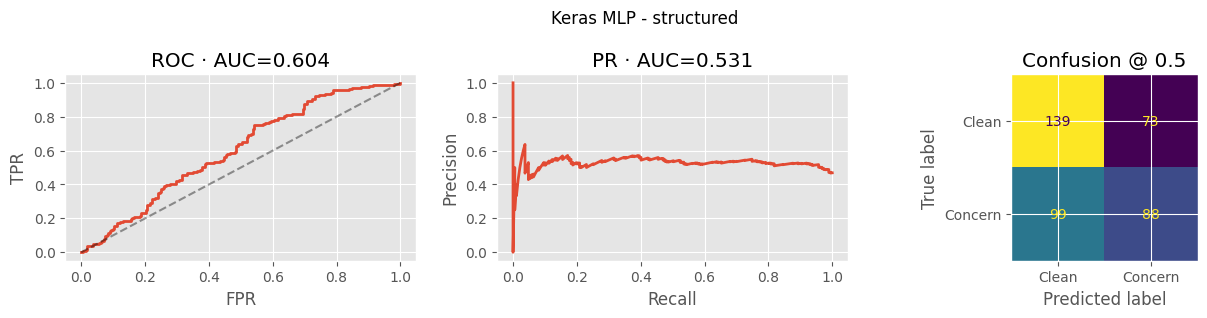

{'model': 'Keras MLP - structured',
 'accuracy': 0.569,
 'precision': 0.547,
 'recall': 0.471,
 'f1': 0.506,
 'roc_auc': np.float64(0.604),
 'pr_auc': np.float64(0.531)}

In [ ]:
es = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
hist_mlp = mlp_struct.fit(Xtr_s, tr_df['label'].values.astype('float32'),
                          validation_data=(Xva_s, va_df['label'].values.astype('float32')),
                          epochs=40, batch_size=64, callbacks=[es], verbose=0)

plt.figure(figsize=(5,3))
plt.plot(hist_mlp.history['accuracy'], c='r'); plt.plot(hist_mlp.history['val_accuracy'], c='b')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(['Training','Validation'])
plt.title('MLP (structured) — learning curve'); plt.tight_layout(); plt.show()

va_prob_mlp = mlp_struct.predict(Xva_s, verbose=0).ravel()
r = evaluate(va_df['label'], va_prob_mlp, 'Keras MLP - structured', show_plots=True)
results.append(r); r


## Text Head: Pre-Trained RoBERTa via `keras_hub`

We load the RoBERTa-base backbone and its tokenizer with `keras_hub.models.Backbone.from_preset("roberta_base_en")`, pack sequences to 512 tokens with `keras_hub.layers.StartEndPacker`, extract the **CLS token** embedding (`x = x[:, 0, :]`), and use that 768-dim vector as the text representation.

We keep the backbone **frozen** (`backbone.trainable = False`) because our per-class sample size (~1,850 training restaurants) is far below the scale needed to fine-tune 125 M RoBERTa parameters without overfitting.


In [ ]:
# RoBERTa tokenizer + backbone
tokenizer = keras_hub.models.Tokenizer.from_preset('roberta_base_en')
backbone  = keras_hub.models.Backbone.from_preset('roberta_base_en')
backbone.trainable = False
print('RoBERTa output shape:', backbone.output.shape)


100%|██████████| 445/445 [00:00<00:00, 1.03MB/s]


100%|██████████| 686/686 [00:00<00:00, 1.09MB/s]


100%|██████████| 0.99M/0.99M [00:00<00:00, 36.3MB/s]


100%|██████████| 446k/446k [00:00<00:00, 26.1MB/s]


100%|██████████| 474M/474M [00:04<00:00, 119MB/s] 


RoBERTa output shape: (None, None, 768)


In [ ]:
SEQ_LEN = 512

def make_text_ds(df_split, batch=16):
    ds = tf.data.Dataset.from_tensor_slices((df_split['text'].values,
                                             df_split['label'].values.astype('float32')))
    packer = keras_hub.layers.StartEndPacker(
        sequence_length=SEQ_LEN,
        start_value=tokenizer.start_token_id,
        end_value=tokenizer.end_token_id,
        pad_value=tokenizer.pad_token_id,
        return_padding_mask=True,
    )
    def _pre(text, label):
        token_ids, padding_mask = packer(tokenizer(text))
        return {'token_ids': token_ids, 'padding_mask': padding_mask}, label
    return ds.map(_pre).batch(batch).prefetch(tf.data.AUTOTUNE)

tr_txt_ds = make_text_ds(tr_df)
va_txt_ds = make_text_ds(va_df)
te_txt_ds = make_text_ds(te_df)


In [ ]:
# encode all reviews to 768-dim CLS vectors once and cache
TEXT_EMB_CACHE = os.path.join(CACHE_DIR, 'text_emb.npz')

if os.path.exists(TEXT_EMB_CACHE):
    z = np.load(TEXT_EMB_CACHE)
    Ttr, Tva, Tte = z['Ttr'], z['Tva'], z['Tte']
    print('loaded text embeddings from cache', Ttr.shape, Tva.shape, Tte.shape)
else:
    # tiny encoder-only model that outputs the CLS embedding
    cls_model = keras.Model(backbone.input, backbone.output[:, 0, :], name='roberta_cls')

    def encode(ds):
        chunks = []
        for batch, _ in ds:
            chunks.append(cls_model(batch, training=False).numpy())
        return np.concatenate(chunks, axis=0)

    Ttr = encode(tr_txt_ds); Tva = encode(va_txt_ds); Tte = encode(te_txt_ds)
    np.savez_compressed(TEXT_EMB_CACHE, Ttr=Ttr, Tva=Tva, Tte=Tte)
    print('encoded & cached', Ttr.shape, Tva.shape, Tte.shape)


loaded text embeddings from cache (1856, 768) (399, 768) (398, 768)


### Text Baseline: `TextVectorization` + trainable `Embedding`

This is a *second* text baseline, where `TextVectorization` → `Embedding` → `Bidirectional(LSTM)` → sigmoid.


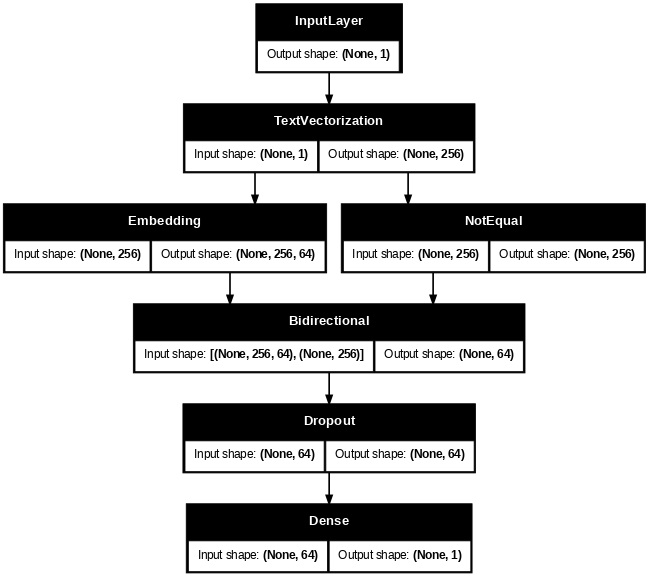

In [ ]:
vec = layers.TextVectorization(max_tokens=20000, output_sequence_length=256)
vec.adapt(tr_df['text'].values)

# Bi-LSTM classifier
tin = layers.Input(shape=(1,), dtype='string', name='review_text')
x = vec(tin)
x = layers.Embedding(input_dim=20000, output_dim=64, mask_zero=True)(x)
x = layers.Bidirectional(layers.LSTM(32))(x)
x = layers.Dropout(0.4)(x)
tout = layers.Dense(1, activation='sigmoid')(x)
text_rnn = keras.Model(tin, tout, name='text_rnn_baseline')
text_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
keras.utils.plot_model(text_rnn, show_shapes=True, dpi=60)

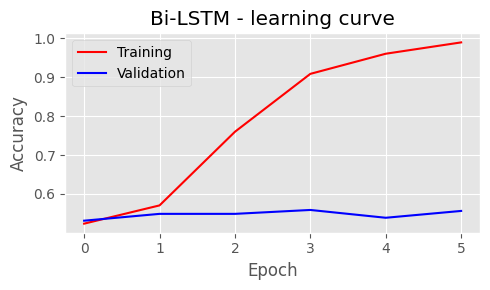

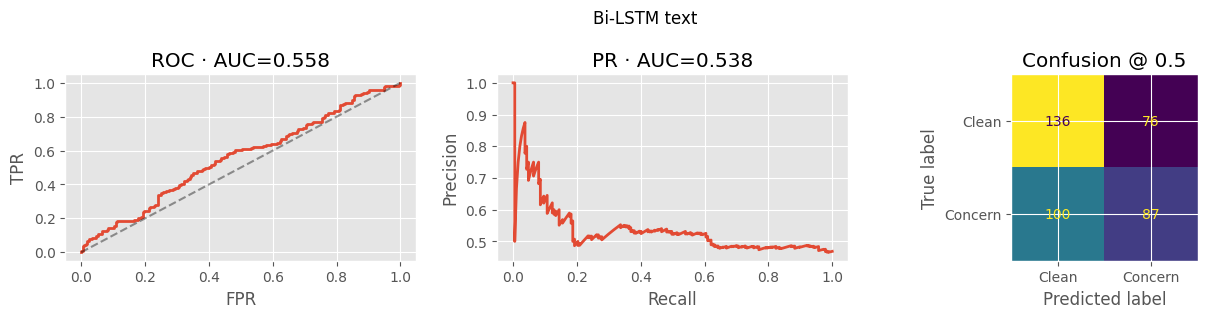

{'model': 'Bi-LSTM text',
 'accuracy': 0.559,
 'precision': 0.534,
 'recall': 0.465,
 'f1': 0.497,
 'roc_auc': np.float64(0.558),
 'pr_auc': np.float64(0.538)}

In [ ]:
es = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
hist_rnn = text_rnn.fit(tr_df['text'].values, tr_df['label'].values.astype('float32'),
                        validation_data=(va_df['text'].values, va_df['label'].values.astype('float32')),
                        epochs=6, batch_size=32, callbacks=[es], verbose=0)

plt.figure(figsize=(5,3))
plt.plot(hist_rnn.history['accuracy'], c='r'); plt.plot(hist_rnn.history['val_accuracy'], c='b')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(['Training','Validation'])
plt.title('Bi-LSTM - learning curve'); plt.tight_layout(); plt.show()

va_prob_rnn = text_rnn.predict(va_df['text'].values, verbose=0).ravel()
r = evaluate(va_df['label'], va_prob_rnn, 'Bi-LSTM text', show_plots=True)
results.append(r); r


## Image Head with Pre-Trained VGG16 via keras.applications

We load VGG16 with ImageNet weights and `include_top=False`, freeze it, and use it as a fixed feature extractor.

Per restaurant, we:
1. Load up to 10 Yelp reviewer photos
2. Resize each to 224 × 224, and apply keras.applications.vgg16 and preprocess_input.
3. Forward through the frozen backbone, global-max-pool to a 512-dim vector.
4. Mean-pool across that restaurant's photos to a single 512-dim restaurant vector.

Mean-pooling (rather than attention) is the right inductive bias at this sample size because the median restaurant has 4 photos and attention with so few elements collapses to roughly uniform weights.

In [ ]:
# photo to business mapping
photos_by_biz = (photos_meta.groupby('business_id')['photo_id']
                            .apply(list).to_dict())
print('restaurants with at least one photo:', len(photos_by_biz))
print('total photo_id rows in mapping     :', sum(len(v) for v in photos_by_biz.values()))


restaurants with at least one photo: 1771
total photo_id rows in mapping     : 11877


In [ ]:
# frozen VGG16 feature extractor
IMG_SIZE = 224

vgg_base = keras.applications.VGG16(weights='imagenet',
                                    include_top=False,
                                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
vgg_base.trainable = False

# functional model: input → VGG16 → GlobalMaxPool → 512-dim vector
img_in  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
x = keras.applications.vgg16.preprocess_input(img_in)
x = vgg_base(x, training=False)
img_vec = layers.GlobalMaxPooling2D(name='vgg_pool')(x)
photo_encoder = keras.Model(img_in, img_vec, name='vgg16_frozen_encoder')
photo_encoder.summary()


Model: "vgg16_frozen_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg_pool            │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# encode one restaurant's photos, mean-pooled to a single 512-dim vec
from PIL import Image as PILImage

def _load_resized(photo_id, size=IMG_SIZE):
    p = os.path.join(PHOTOS_DIR, f'{photo_id}.jpg')
    if not os.path.exists(p):
        return None
    try:
        img = PILImage.open(p).convert('RGB').resize((size, size))
        return np.asarray(img, dtype='float32')
    except Exception:
        return None

def encode_restaurant_photos(biz_id, max_photos=10):
    pids = photos_by_biz.get(biz_id, [])[:max_photos]
    arrs = [a for a in (_load_resized(p) for p in pids) if a is not None]
    if not arrs:
        return np.zeros(512, dtype='float32'), 0
    batch = np.stack(arrs, axis=0)
    vecs = photo_encoder.predict(batch, verbose=0)
    return vecs.mean(axis=0).astype('float32'), len(arrs)


In [ ]:
# build per-restaurant image matrices (with on-disk caching)
IMG_EMB_CACHE = os.path.join(CACHE_DIR, 'image_emb.npz')

def build_image_matrix(df_split, cache_key):
    out = np.zeros((len(df_split), 512), dtype='float32')
    mask = np.zeros(len(df_split), dtype='float32')
    for i, biz in enumerate(df_split['business_id'].values):
        vec, n = encode_restaurant_photos(biz)
        out[i] = vec; mask[i] = 1.0 if n > 0 else 0.0
    return out, mask

if os.path.exists(IMG_EMB_CACHE):
    z = np.load(IMG_EMB_CACHE)
    Itr, Iva, Ite, Mtr, Mva, Mte = z['Itr'], z['Iva'], z['Ite'], z['Mtr'], z['Mva'], z['Mte']
    print('loaded image embeddings from cache', Itr.shape)
else:
    Itr, Mtr = build_image_matrix(tr_df, 'tr')
    Iva, Mva = build_image_matrix(va_df, 'va')
    Ite, Mte = build_image_matrix(te_df, 'te')
    np.savez_compressed(IMG_EMB_CACHE, Itr=Itr, Iva=Iva, Ite=Ite, Mtr=Mtr, Mva=Mva, Mte=Mte)
    print('encoded & cached', Itr.shape, Iva.shape, Ite.shape)


loaded image embeddings from cache (1856, 512)


## Final Model: FusionNet Multi-Modal Classifier

Our central model with hree modality-specific heads, merged with `layers.Concatenate()` in the Functional API.

**Why three small heads and not one giant concat?** Separate modality heads force each stream to compress into a dense representation *before* they interact. This is a well-documented form of implicit regularization in multimodal fusion.

**Regularization defaults.** ReLU, dropout = 0.3, `adam`, `binary_crossentropy`.


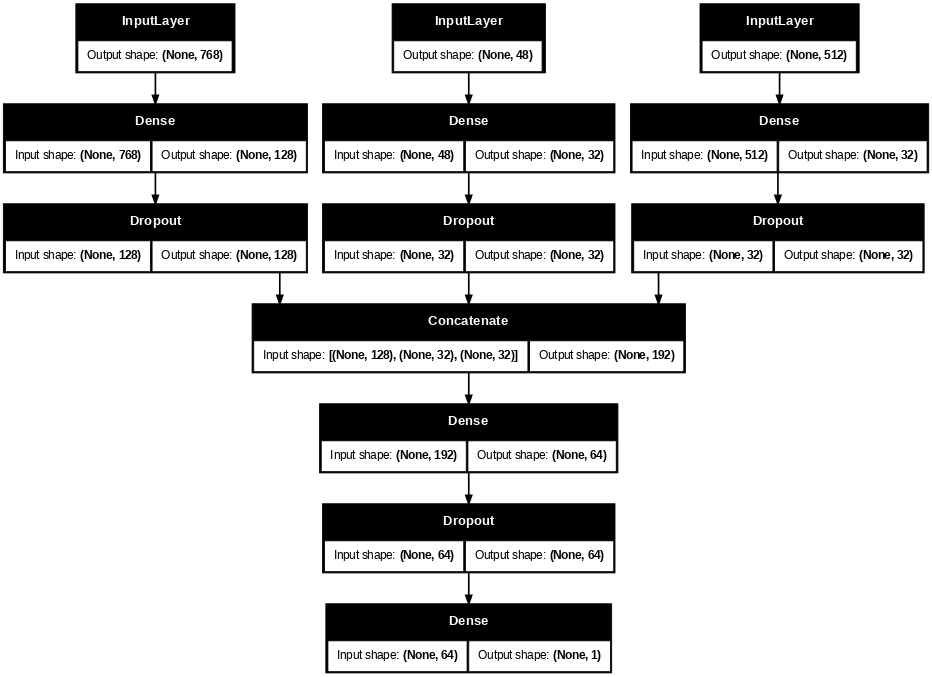

In [ ]:
# FusionNet model build
def build_fusionnet(text_dim, struct_dim, img_dim,
                    hidden_text=128, hidden_struct=32, hidden_img=32,
                    hidden_joint=64, dropout=0.3):

    # text branch
    text_in = layers.Input(shape=(text_dim,), name='text_emb')
    t = layers.Dense(hidden_text, activation='relu')(text_in)
    t = layers.Dropout(dropout)(t)

    # structured branch
    struct_in = layers.Input(shape=(struct_dim,), name='struct_feat')
    s = layers.Dense(hidden_struct, activation='relu')(struct_in)
    s = layers.Dropout(dropout)(s)

    # image branch
    img_in = layers.Input(shape=(img_dim,), name='image_emb')
    g = layers.Dense(hidden_img, activation='relu')(img_in)
    g = layers.Dropout(dropout)(g)

    # multimodal merge
    merge = layers.Concatenate()([t, s, g])
    h = layers.Dense(hidden_joint, activation='relu')(merge)
    h = layers.Dropout(dropout)(h)
    out = layers.Dense(1, activation='sigmoid', name='label')(h)

    model = keras.Model(inputs=[text_in, struct_in, img_in], outputs=out, name='fusionnet')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

fusion = build_fusionnet(Ttr.shape[1], Xtr_s.shape[1], Itr.shape[1])
keras.utils.plot_model(fusion, show_shapes=True, dpi=60)


In [ ]:
fusion.summary()

Model: "fusionnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_emb            │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ struct_feat         │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_emb           │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     98,432 │ text_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      1,568 │ struct_feat[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │     16,416 │ image_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ dense_4[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 32)        │          0 │ dense_5[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 32)        │          0 │ dense_6[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout_16[0][0], │
│ (Concatenate)       │                   │            │ dropout_17[0][0], │
│                     │                   │            │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │     12,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 64)        │          0 │ dense_7[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (Dense)       │ (None, 1)         │         65 │ dropout_19[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 128,833 (503.25 KB)

 Trainable params: 128,833 (503.25 KB)

 Non-trainable params: 0 (0.00 B)

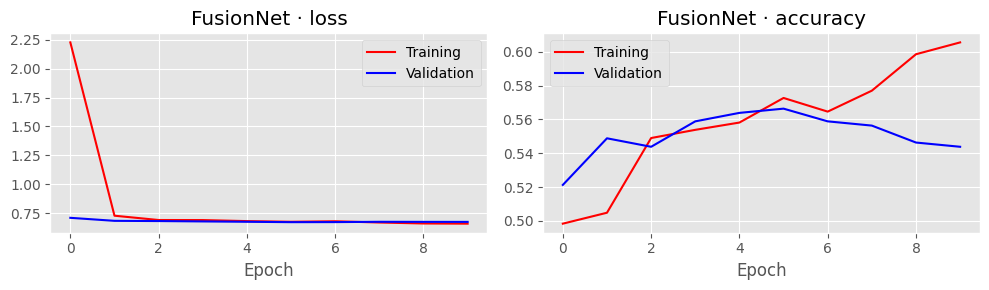

In [ ]:
# training FusionNet
cb = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=0),
]

hist_full = fusion.fit(
    x=[Ttr, Xtr_s, Itr], y=tr_df['label'].values.astype('float32'),
    validation_data=([Tva, Xva_s, Iva], va_df['label'].values.astype('float32')),
    epochs=40, batch_size=64, callbacks=cb, verbose=0,
)

# learning curves — class-standard visualisation
fig, axes = plt.subplots(1, 2, figsize=(10,3))
axes[0].plot(hist_full.history['loss'], c='r'); axes[0].plot(hist_full.history['val_loss'], c='b')
axes[0].set_title('FusionNet · loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(['Training','Validation'])
axes[1].plot(hist_full.history['accuracy'], c='r'); axes[1].plot(hist_full.history['val_accuracy'], c='b')
axes[1].set_title('FusionNet · accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(['Training','Validation'])
plt.tight_layout(); plt.show()


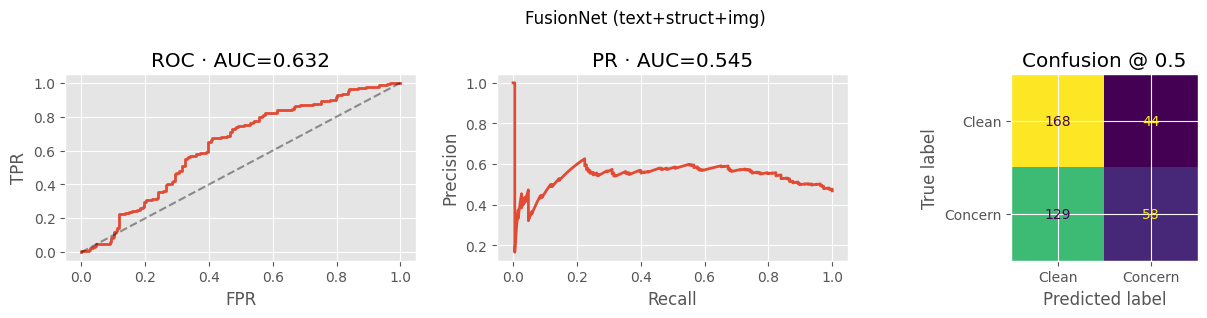

{'model': 'FusionNet (text+struct+img)',
 'accuracy': 0.566,
 'precision': 0.569,
 'recall': 0.31,
 'f1': 0.401,
 'roc_auc': np.float64(0.632),
 'pr_auc': np.float64(0.545)}

In [ ]:
va_prob_full = fusion.predict([Tva, Xva_s, Iva], verbose=0).ravel()
r = evaluate(va_df['label'], va_prob_full, 'FusionNet (text+struct+img)', show_plots=True)
results.append(r); r


## Does each branch actually help?

We mask each modality in turn (replace its embedding with zeros at inference time) and re-score on validation. If the scores drop when a modality is masked, that modality is contributing independent information; if they don't, the model is ignoring that branch.


In [ ]:
def ablate(fusion_model, T, S, I, y, name):
    zT = np.zeros_like(T); zS = np.zeros_like(S); zI = np.zeros_like(I)
    configs = {
        'all three (full)'   : [T,  S,  I ],
        'text only'          : [T,  zS, zI],
        'struct only'        : [zT, S,  zI],
        'image only'         : [zT, zS, I ],
        'text + struct'      : [T,  S,  zI],
        'text + image'       : [T,  zS, I ],
        'struct + image'     : [zT, S,  I ],
    }
    rows = []
    for cfg_name, cfg in configs.items():
        p = fusion_model.predict(cfg, verbose=0).ravel()
        rows.append({'config': cfg_name,
                     'val_acc': round(accuracy_score(y, (p>=0.5).astype(int)), 3),
                     'val_auc': round(roc_auc_score(y, p), 3),
                     'val_pr' : round(average_precision_score(y, p), 3)})
    return pd.DataFrame(rows)

abl = ablate(fusion, Tva, Xva_s, Iva, va_df['label'], 'val')
abl


,config,val_acc,val_auc,val_pr
0,all three (full),0.566,0.632,0.545
1,text only,0.584,0.619,0.577
2,struct only,0.546,0.600,0.514
3,image only,0.526,0.496,0.471
4,text + struct,0.559,0.624,0.534
5,text + image,0.584,0.628,0.573
6,struct + image,0.549,0.604,0.525


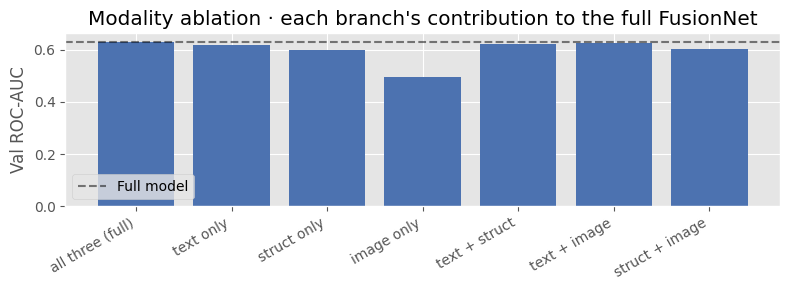

In [ ]:
# ablation effects as a bar chart
plt.figure(figsize=(8,3))
plt.bar(abl['config'], abl['val_auc'], color='#4C72B0')
plt.axhline(abl.loc[abl['config']=='all three (full)','val_auc'].iloc[0],
            color='k', linestyle='--', alpha=0.5, label='Full model')
plt.xticks(rotation=30, ha='right'); plt.ylabel('Val ROC-AUC')
plt.title('Modality ablation · each branch\'s contribution to the full FusionNet')
plt.legend(); plt.tight_layout(); plt.show()


## Hyperparameter Exploration


In [ ]:
grid = [(ht, dr, lr)
        for ht in [64, 128, 256]
        for dr in [0.2, 0.3, 0.5]
        for lr in [1e-3, 5e-4, 2e-4]]

sweep_rows = []
for ht, dr, lr in grid:
    m = build_fusionnet(Ttr.shape[1], Xtr_s.shape[1], Itr.shape[1],
                        hidden_text=ht, dropout=dr)
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss='binary_crossentropy', metrics=['accuracy'])
    m.fit([Ttr, Xtr_s, Itr], tr_df['label'].values.astype('float32'),
          validation_data=([Tva, Xva_s, Iva], va_df['label'].values.astype('float32')),
          epochs=20, batch_size=64, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                                   patience=3, restore_best_weights=True)])
    p = m.predict([Tva, Xva_s, Iva], verbose=0).ravel()
    sweep_rows.append({'hidden_text': ht, 'dropout': dr, 'lr': lr,
                       'val_auc': round(roc_auc_score(va_df['label'], p), 3),
                       'val_acc': round(accuracy_score(va_df['label'], (p>=0.5).astype(int)), 3)})

sweep_df = pd.DataFrame(sweep_rows).sort_values('val_auc', ascending=False)
sweep_df.head(10)


,hidden_text,dropout,lr,val_auc,val_acc
3,64,0.3,0.0010,0.641,0.609
18,256,0.2,0.0010,0.641,0.612
15,128,0.5,0.0010,0.628,0.576
6,64,0.5,0.0010,0.623,0.559
9,128,0.2,0.0010,0.617,0.599
10,128,0.2,0.0005,0.611,0.599
0,64,0.2,0.0010,0.607,0.581
24,256,0.5,0.0010,0.605,0.586
14,128,0.3,0.0002,0.600,0.581
22,256,0.3,0.0005,0.599,0.581


In [ ]:
# refit the single best config and save it as `model_best` for test eval
best = sweep_df.iloc[0]
model_best = build_fusionnet(Ttr.shape[1], Xtr_s.shape[1], Itr.shape[1],
                             hidden_text=int(best['hidden_text']),
                             dropout=float(best['dropout']))
model_best.compile(optimizer=keras.optimizers.Adam(float(best['lr'])),
                   loss='binary_crossentropy', metrics=['accuracy'])
model_best.fit([Ttr, Xtr_s, Itr], tr_df['label'].values.astype('float32'),
               validation_data=([Tva, Xva_s, Iva], va_df['label'].values.astype('float32')),
               epochs=40, batch_size=64, verbose=0,
               callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                                        patience=4, restore_best_weights=True)])
print('best config:', dict(best))


best config: {'hidden_text': np.float64(64.0), 'dropout': np.float64(0.3), 'lr': np.float64(0.001), 'val_auc': np.float64(0.641), 'val_acc': np.float64(0.609)}


## Final Test-Set Evaluation


In [ ]:
# rebuilding TF-IDF test preds
te_prob_lr_s  = lr_s.predict_proba(te_df)[:, 1]
te_prob_lr_t  = lr_t.predict_proba(Xte_t)[:, 1]
te_prob_mlp   = mlp_struct.predict(Xte_s, verbose=0).ravel()
te_prob_rnn   = text_rnn.predict(te_df['text'].values, verbose=0).ravel()
te_prob_full  = fusion.predict([Tte, Xte_s, Ite], verbose=0).ravel()
te_prob_best  = model_best.predict([Tte, Xte_s, Ite], verbose=0).ravel()

test_rows = [
    evaluate(te_df['label'], te_prob_lr_s, 'LR — structured + photo-stats (TEST)'),
    evaluate(te_df['label'], te_prob_lr_t, 'LR — TFIDF (TEST)'),
    evaluate(te_df['label'], te_prob_mlp,  'Keras MLP — structured (TEST)'),
    evaluate(te_df['label'], te_prob_rnn,  'Bi-LSTM text — Week 8.2 (TEST)'),
    evaluate(te_df['label'], te_prob_full, 'FusionNet (TEST)'),
    evaluate(te_df['label'], te_prob_best, 'FusionNet — best hparams (TEST)'),
]
pd.DataFrame(test_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LR — TFIDF (TEST),0.618,0.628,0.460,0.531,0.634,0.575
1,Bi-LSTM text — Week 8.2 (TEST),0.585,0.571,0.471,0.516,0.612,0.572
2,LR — structured + photo-stats (TEST),0.573,0.547,0.524,0.536,0.609,0.581
3,FusionNet — best hparams (TEST),0.578,0.564,0.449,0.500,0.604,0.553
4,Keras MLP — structured (TEST),0.580,0.570,0.433,0.492,0.598,0.597
5,FusionNet (TEST),0.553,0.543,0.305,0.390,0.561,0.519


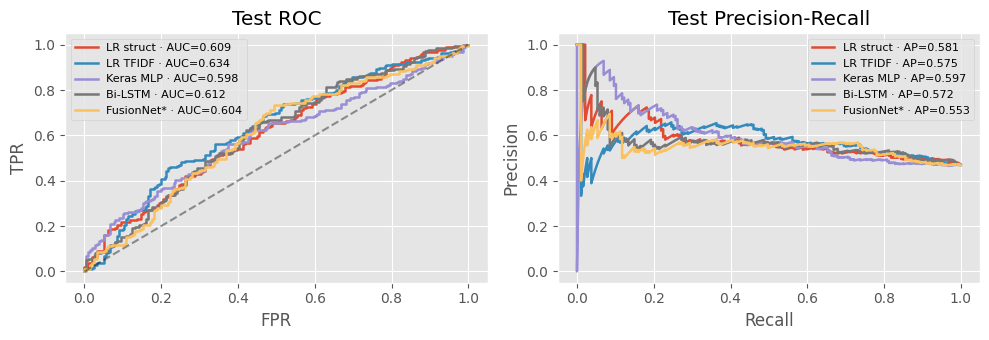

In [ ]:
# overlayed ROC + PR for the final leaderboard
plt.figure(figsize=(10, 3.5))
plt.subplot(1, 2, 1)
for y_prob, name in [
    (te_prob_lr_s, 'LR struct'),
    (te_prob_lr_t, 'LR TFIDF'),
    (te_prob_mlp,  'Keras MLP'),
    (te_prob_rnn,  'Bi-LSTM'),
    (te_prob_best, 'FusionNet*'),
]:
    fpr, tpr, _ = roc_curve(te_df['label'], y_prob)
    plt.plot(fpr, tpr, lw=1.8, label=f'{name} · AUC={roc_auc_score(te_df["label"], y_prob):.3f}')
plt.plot([0,1],[0,1],'k--',alpha=0.4); plt.title('Test ROC'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
for y_prob, name in [
    (te_prob_lr_s, 'LR struct'),
    (te_prob_lr_t, 'LR TFIDF'),
    (te_prob_mlp,  'Keras MLP'),
    (te_prob_rnn,  'Bi-LSTM'),
    (te_prob_best, 'FusionNet*'),
]:
    pr, rc, _ = precision_recall_curve(te_df['label'], y_prob)
    plt.plot(rc, pr, lw=1.8, label=f'{name} · AP={average_precision_score(te_df["label"], y_prob):.3f}')
plt.title('Test Precision-Recall'); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Threshold Tuning

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6]

rows = []
for t in thresholds:
    preds = (te_prob_lr_t >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(te_df['label'], preds),
        "recall": recall_score(te_df['label'], preds),
        "f1": f1_score(te_df['label'], preds)
    })

pd.DataFrame(rows)

,threshold,precision,recall,f1
0,0.3,0.470738,0.989305,0.637931
1,0.4,0.521739,0.834225,0.641975
2,0.5,0.627737,0.459893,0.530864
3,0.6,0.437500,0.037433,0.068966


In [ ]:
best_threshold = 0.4
te_preds_final = (te_prob_lr_t >= best_threshold).astype(int)

## Error Analysis

Where does the FusionNet get things wrong? We inspect the ten highest-confidence *false positives* (model screamed "concern" but inspection was clean) and ten highest-confidence *false negatives* (model said "clean" but the inspection flagged violations).


In [ ]:
te_out = te_df.copy()
te_out['prob'] = te_prob_lr_t
fp = te_out[(te_out['label']==0)].sort_values('prob', ascending=False).head(10)
fn = te_out[(te_out['label']==1)].sort_values('prob', ascending=True).head(10)

print('Top-10 false positives (model said concern, inspection was clean):')
print(fp[['yelp_name','yelp_stars','n_photos','prob']].to_string(index=False))

print('\nTop-10 false negatives (model said clean, inspection found violations):')
print(fn[['yelp_name','yelp_stars','n_photos','prob']].to_string(index=False))


Top-10 false positives (model said concern, inspection was clean):
                            yelp_name  yelp_stars  n_photos     prob
                      Amy's China One         4.0       0.0 0.680786
                      China Crossings         3.0       0.0 0.646388
                              Hot Wok         3.5       0.0 0.631560
                           China King         3.5       0.0 0.629360
         Bayshore Mediterranean Grill         4.5       7.0 0.622797
                  India's Grill Tampa         4.0       7.0 0.614614
                           China Moon         3.5       1.0 0.613978
                     Kao Thai Kitchen         4.5       6.0 0.608302
Tazza Turkish and Mediterranean Grill         4.5      10.0 0.604738
                            China One         4.0       0.0 0.594701

Top-10 false negatives (model said clean, inspection found violations):
                  yelp_name  yelp_stars  n_photos     prob
                   Culver's         3.5   

## Conclusions

- The strongest test model was TF-IDF logistic regression, suggesting that review language contains the clearest hygiene-related signal.
- FusionNet performed competitively but did not beat the best text baseline on the test set.
- The image branch added limited value, likely because only 67% of restaurants have photos and most photos show food/ambience rather than cleanliness.
- The task is inherently noisy because Yelp reviews and photos are indirect signals, while the label comes from a single inspection date.

**Caveats worth mentioning:**

1. **Temporal mismatch.** Yelp reviews end Jan-2022; DBPR inspections are FY 2024-25. The model is learning "restaurants *as of early 2022* that will have hygiene issues two-plus years later", so it's a useful signal, but an inherently lagged one.
2. **Photo coverage is uneven.** Only 67% of restaurants have any Yelp photos, and the median is 4. The image branch therefore runs zero-masked on a third of the data. The `has_photos` flag lets the model learn to ignore the image branch there, but the signal is literally missing.
3. **Label noise.** "High-priority violation" on a single inspection date is a noisy, infrequent measurement of true hygiene. A longitudinal version of this target (repeat-violator flag over multiple inspections) would be stronger.

## Future Work

- **Per-photo attention.** Replace mean-pooling over the 10 photo embeddings with a tiny attention head.
- **Per-review attention.** Same idea for text, with the RoBERTa CLS from each individual review going through an attention pool instead of concatenating.
- **End-to-end fine-tuning.** With 10× more data (e.g. pool TX + CA + FL reviews) unfreeze the top RoBERTa and VGG16 blocks.
- **Recall-first threshold.** Currently we report @ 0.5. A public-health use-case would tune for recall subject to a precision floor.
- **Fairness audit.** Stratify test-set error rates by cuisine and county. If the model systematically over-flags one cuisine, flag it honestly — this aligns with the proposal's "socially relevant" framing.
- **External validation.** Run the frozen FusionNet on Yelp × health-department data from a second city (e.g. Philadelphia) without retraining.
